In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rapidfuzz import process, fuzz
# from utils import convert_to_float

/Users/debodeepbanerjee/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/debodeepbanerjee/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('/Users/debodeepbanerjee/Library/CloudStorage/OneDrive-Personal/Documents/desidata/rural_internet/BharatnetServiceReadyGPs31012026.csv')

In [3]:
df['District'] = [i.capitalize() for i in df.District]
df

,State,District,Total Gram Panchayats,Service Ready Gram Panchayats,Proportion
0,ANDAMAN AND NICOBAR ISLANDS,Nicobars,3,3,100.0
1,ANDAMAN AND NICOBAR ISLANDS,North and middle andaman,37,37,100.0
2,ANDAMAN AND NICOBAR ISLANDS,South andamans,30,30,100.0
3,ANDHRA PRADESH,Anantapur,1044,996,95.4
4,ANDHRA PRADESH,Chittoor,1412,1193,84.5
...,...,...,...,...,...
671,WEST BENGAL,Murshidabad,250,250,100.0
672,WEST BENGAL,Nadia,185,185,100.0
673,WEST BENGAL,Paschim bardhaman,62,56,90.3
674,WEST BENGAL,Purba bardhaman,215,146,67.9


In [4]:
map_data = gpd.read_file('/Users/debodeepbanerjee/Library/CloudStorage/OneDrive-Personal/Documents/desidata/india_shp_2020/district/in_district.shp')
map_data['dtname'] = [i.capitalize() for i in map_data.dtname]

In [5]:
map_data

,dtname,stname,stcode11,dtcode11,year_stat,Dist_LGD,State_LGD,JID,geometry
0,Kupwara,JAMMU & KASHMIR,01,001,2011_c,8.0,1.0,598,"POLYGON ((74.33744 34.78209, 74.34695 34.78019..."
1,Bandipore,JAMMU & KASHMIR,01,009,2011_c,623.0,1.0,599,"POLYGON ((74.73338 34.67121, 74.74956 34.66883..."
2,Baramula,JAMMU & KASHMIR,01,008,2011_c,3.0,1.0,600,"POLYGON ((74.51946 34.42533, 74.52090 34.42237..."
3,Ganderbal,JAMMU & KASHMIR,01,011,2011_c,626.0,1.0,601,"POLYGON ((74.94144 34.46384, 74.94554 34.46247..."
4,Anantnag,JAMMU & KASHMIR,01,014,2011_c,1.0,1.0,602,"POLYGON ((75.26949 34.25584, 75.27242 34.25356..."
...,...,...,...,...,...,...,...,...,...
730,Bhadradri kothagudem,TELANGANA,36,753,2016_c,690.0,36.0,193,"POLYGON ((80.84343 18.23581, 80.84990 18.23582..."
731,Jayashankar,TELANGANA,36,750,2016_c,687.0,36.0,718,"POLYGON ((80.34314 18.59811, 80.34149 18.59770..."
732,Narayanpet,TELANGANA,36,781,2019,721.0,36.0,719,"POLYGON ((77.76028 17.00224, 77.76004 17.00144..."
733,Leh,LADAKH,37,003,2019,9.0,37.0,596,"POLYGON ((74.73354 37.02003, 74.73551 37.01872..."


<Axes: >

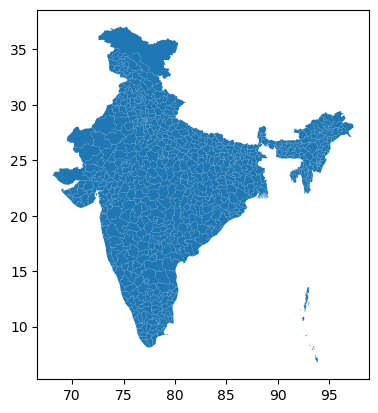

In [6]:
map_data.plot()

In [7]:
from thefuzz import process

def fuzzy_match(name, choices, threshold=80):
    match, score = process.extractOne(name, choices)
    return match if score >= threshold else None

district_name_map = {
    'North & middle andaman': 'North and middle andaman',
    'South andaman': 'South andamans',
    'Punch': 'Poonch',
    'Puducherry':'Pondicherry',
    'Koriya':'Korea',
    'Purba medinipur':'Medinipur east',
    # keep adding as you find them
}

df_districts = df['District'].tolist()
map_data['dtname_clean'] = map_data['dtname'].apply(
    lambda x: district_name_map.get(x, fuzzy_match(x, df_districts))
)

merged = map_data.set_index('dtname_clean').join(df.set_index('District'))
merged = merged.reset_index()

In [8]:
merged[merged['stname'] == 'WEST BENGAL']

,dtname_clean,dtname,stname,stcode11,dtcode11,year_stat,Dist_LGD,State_LGD,JID,geometry,State,Total Gram Panchayats,Service Ready Gram Panchayats,Proportion
376,South andamans,South twenty four pargan*,WEST BENGAL,19,343,2011_c,304.0,19.0,165,"MULTIPOLYGON (((88.57445 22.61864, 88.57492 22...",ANDAMAN AND NICOBAR ISLANDS,30.0,30.0,100.0
377,Darjeeling,Darjiling,WEST BENGAL,19,327,2011_c,309.0,19.0,264,"POLYGON ((88.04002 27.22062, 88.04348 27.21907...",WEST BENGAL,92.0,22.0,23.9
378,Jalpaiguri,Jalpaiguri,WEST BENGAL,19,328,2011_c,314.0,19.0,272,"POLYGON ((88.92027 26.99427, 88.92632 26.98803...",WEST BENGAL,80.0,80.0,100.0
379,Dinajpur dakshin,Dakshin dinajpur,WEST BENGAL,19,331,2011_c,310.0,19.0,346,"POLYGON ((88.40204 25.60814, 88.40283 25.60810...",WEST BENGAL,64.0,42.0,65.6
380,Maldah,Maldah,WEST BENGAL,19,332,2011_c,316.0,19.0,347,"POLYGON ((87.95961 25.53857, 87.95958 25.53807...",WEST BENGAL,146.0,109.0,74.7
381,Murshidabad,Murshidabad,WEST BENGAL,19,333,2011_c,319.0,19.0,383,"POLYGON ((87.89765 24.85942, 87.89871 24.85624...",WEST BENGAL,250.0,250.0,100.0
382,Birbhum,Birbhum,WEST BENGAL,19,334,2011_c,307.0,19.0,395,"POLYGON ((87.79303 24.58363, 87.79333 24.58352...",WEST BENGAL,167.0,167.0,100.0
383,Nadia,Nadia,WEST BENGAL,19,336,2011_c,320.0,19.0,412,"POLYGON ((88.72420 24.10433, 88.72560 24.10342...",WEST BENGAL,185.0,185.0,100.0
384,Purba bardhaman,Purba bardhaman,WEST BENGAL,19,335,2011_c,306.0,19.0,425,"POLYGON ((88.00906 23.84558, 88.00901 23.84474...",WEST BENGAL,215.0,146.0,67.9
385,Purulia,Puruliya,WEST BENGAL,19,340,2011_c,321.0,19.0,433,"POLYGON ((86.80536 23.69619, 86.80597 23.69586...",WEST BENGAL,170.0,170.0,100.0


In [9]:
# merged = map_data.set_index('dtname').join(df.set_index('District'))

In [10]:
merged.shape

(746, 14)

In [11]:
merged_nans = merged[merged.isnull().any(axis=1)]
merged_nans.shape
# merged

(45, 14)

In [12]:
# merged_nans#['stname'].unique()

<Figure size 14400x9600 with 0 Axes>

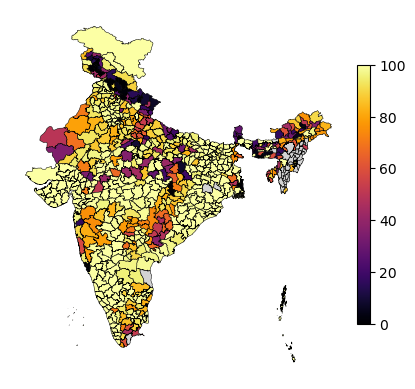

In [13]:
def convert_to_float(value):
    """
    Convert a value to a float. If the value is a string, remove commas and convert to float.
    If the value is NaN or invalid, return NaN.
    """
    try:
        # Handle strings: Remove commas and convert to float
        if isinstance(value, str):
            return float(value.replace(',', ''))
        # Handle numbers: Return as float
        elif isinstance(value, (int, float)):
            return float(value)
        else:
            # For unsupported types, return NaN
            return np.nan
    except (ValueError, TypeError):
        # Handle any conversion error
        return np.nan
        
# def plot_map(merged, column, save_path, r_start, g_start, b_start, r_end, g_end, b_end):
r_start, g_start, b_start = 255, 255, 245
r_end,   g_end,   b_end   = 220, 180, 0
save_path = '/Users/debodeepbanerjee/Library/CloudStorage/OneDrive-Personal/Documents/desidata/rural_internet'
# plot_map(merged,
# merged['Proportion'], 
column = 'Proportion'
"""
merged: pd.DataFrame
column: str
save_path: str
r_start, g_start, b_start: int (start RGB values)
r_end, g_end, b_end: int (end RGB values)
"""
# Create a color map
N = 256
vals = np.ones((N, 4))
start_color = [r_start / 255, g_start / 255, b_start / 255]
end_color = [r_end / 255, g_end / 255, b_end / 255]
vals[:, 0] = np.linspace(start_color[0], end_color[0], N)
vals[:, 1] = np.linspace(start_color[1], end_color[1], N)
vals[:, 2] = np.linspace(start_color[2], end_color[2], N)
# cmap = ListedColormap(vals)
cmap = 'inferno'

# print(merged[column])
# check if merged has any strings in the specified column
# merged[column] = [float(v) for v in list(merged[column])]
# print(merged[column])
# Plot the data
fig = plt.figure(figsize=(12, 8), dpi=1200)
ax = merged.plot(column=column, cmap=cmap, 
                 edgecolor='black', linewidth=0.35,
                 missing_kwds={                 # Handle NaN (missing data)
                    "color": "lightgray",      # Color for NaN states
                    "edgecolor": "black",      # Edge color for states
                    "label": "No Data"}
                )

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(
        vmin=merged[column].min(skipna=True), 
        vmax=merged[column].max(skipna=True)
    ))
# sm._A = []
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.7)

# Remove axis ticks and frame
plt.xticks([])
plt.yticks([])
ax.set_frame_on(False)
# plt.title('Monthly Mean Earnings from Self Employment in Transport, Hotels, and Accomodation,\n Nominal INR, States and UT, 2022-23,  All India')
# Save the plot
# plt.savefig(f'{save_path}/{column}.svg', bbox_inches='tight')
# plt.savefig(f'{save_path}/{column}.png', bbox_inches='tight')
# logging.info(f"Plot saved successfully at {save_path}/{column}.svg")
# plt.close(fig)
plt.show()

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.animation import FFMpegWriter
import numpy as np
import matplotlib
matplotlib.use('Agg')

# ── Config — change these ─────────────────────────────────────────────────────
MERGED_PATH = "./merged.gpkg"        # <-- your merged GeoDataFrame saved as file
COLUMN      = "Proportion"          # <-- column to visualize
SAVE_PATH   = "./internet_anim.mp4"
TITLE       = "Internet Penetration in Rural India\nDistrict-wise"

# RGB gradient
r_start, g_start, b_start = 255, 255, 245
r_end,   g_end,   b_end   = 220, 180, 0

# Animation settings
FPS            = 30
DISTRICTS_PER_FRAME = 1   # how many districts revealed per frame
HOLD_FRAMES    = FPS * 2  # hold on final frame

# ── Load data ─────────────────────────────────────────────────────────────────
# If you don't have it saved, replace with your merged GeoDataFrame directly
# merged = gpd.read_file(MERGED_PATH)
# OR just pass merged directly if running in same session

# ── Build colormap ────────────────────────────────────────────────────────────
N    = 256
vals = np.ones((N, 4))
vals[:, 0] = np.linspace(r_start/255, r_end/255, N)
vals[:, 1] = np.linspace(g_start/255, g_end/255, N)
vals[:, 2] = np.linspace(b_start/255, b_end/255, N)
# cmap = ListedColormap(vals)
cmap = 'inferno'

def animate_map(merged):
    # Clean column
    merged[COLUMN] = pd.to_numeric(merged[COLUMN], errors='coerce')

    # Sort north to south by centroid latitude
    merged = merged.copy()
    merged['_lat'] = merged.geometry.centroid.y
    merged = merged.sort_values('_lat', ascending=False).reset_index(drop=True)

    n_districts = len(merged)
    vmin = merged[COLUMN].min(skipna=True)
    vmax = merged[COLUMN].max(skipna=True)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # Total frames
    n_reveal_frames = int(np.ceil(n_districts / DISTRICTS_PER_FRAME))
    total_frames    = n_reveal_frames + HOLD_FRAMES

    print(f"Districts  : {n_districts}")
    print(f"Frames     : {total_frames} ({total_frames/FPS:.1f}s)")
    print(f"Rendering...")

    fig, ax = plt.subplots(figsize=(10, 13), facecolor='#B1DDF1')
    ax.set_facecolor('#B1DDF1')
    ax.set_axis_off()

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.5, aspect=20)
    cbar.set_label(COLUMN, fontsize=10)

    ax.set_title(TITLE, fontsize=13, fontweight='bold', pad=15)

    writer = FFMpegWriter(fps=FPS, bitrate=5000)

    import time
    t0 = time.time()
    frame_count = 0

    with writer.saving(fig, SAVE_PATH, dpi=120):
        for frame in range(total_frames):
            ax.cla()
            ax.set_facecolor('#F5F5F5')
            ax.set_axis_off()
            ax.set_title(TITLE, fontsize=13, fontweight='bold', pad=15, color='black')

            # How many districts revealed so far
            n_shown = min(
                (frame + 1) * DISTRICTS_PER_FRAME,
                n_districts
            )

            # Uncolored districts — light gray
            merged.plot(ax=ax, color='#E8E8E8',
                        edgecolor='#CCCCCC', linewidth=0.2)

            # Colored districts revealed so far
            revealed = merged.iloc[:n_shown]
            revealed.plot(
                ax=ax,
                column=COLUMN,
                cmap=cmap,
                vmin=vmin, vmax=vmax,
                edgecolor='#888888',
                linewidth=0.1,
                missing_kwds={"color": "lightgray",
                              "edgecolor": "#CCCCCC"}
            )

            # Progress label
            pct = 100 * n_shown / n_districts
            ax.text(0.02, 0.02, f"{n_shown}/{n_districts} districts  ({pct:.0f}%)",
                    transform=ax.transAxes,
                    fontsize=8, color='#666666',
                    va='bottom')

            ax.text(0.98, 0.02, "@desidata.info",
                    transform=ax.transAxes,
                    fontsize=8, color='#AAAAAA',
                    ha='right', va='bottom', style='italic')

            writer.grab_frame()
            frame_count += 1

            if frame_count % 30 == 0:
                elapsed   = time.time() - t0
                fps_real  = frame_count / elapsed
                remaining = (total_frames - frame_count) / fps_real
                print(f"  [{100*frame_count/total_frames:.1f}%] "
                      f"frame {frame_count}/{total_frames} | "
                      f"{fps_real:.1f} fps | "
                      f"~{remaining/60:.1f} min remaining")

    print(f"\nDone → {SAVE_PATH}")

# ── Run ───────────────────────────────────────────────────────────────────────
# Call this from your notebook/script with your merged GeoDataFrame:
#
#   import pandas as pd
#   from animate_districts import animate_map
#   animate_map(merged)
#
# OR uncomment below if running standalone:
# import pandas as pd
# merged = gpd.read_file(MERGED_PATH)
animate_map(merged)

/var/folders/bd/079_zcc559lg9qp5q3cgmqcr0000gn/T/ipykernel_11858/1832267642.py:44: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged['_lat'] = merged.geometry.centroid.y


Districts  : 746
Frames     : 806 (26.9s)
Rendering...
  [3.7%] frame 30/806 | 0.2 fps | ~61.1 min remaining
  [7.4%] frame 60/806 | 0.2 fps | ~57.2 min remaining
  [11.2%] frame 90/806 | 0.2 fps | ~59.3 min remaining
  [14.9%] frame 120/806 | 0.2 fps | ~58.4 min remaining
  [18.6%] frame 150/806 | 0.2 fps | ~57.1 min remaining
  [22.3%] frame 180/806 | 0.2 fps | ~55.4 min remaining
  [26.1%] frame 210/806 | 0.2 fps | ~53.5 min remaining
  [29.8%] frame 240/806 | 0.2 fps | ~51.4 min remaining
  [33.5%] frame 270/806 | 0.2 fps | ~49.5 min remaining
  [37.2%] frame 300/806 | 0.2 fps | ~47.8 min remaining
  [40.9%] frame 330/806 | 0.2 fps | ~45.5 min remaining
  [44.7%] frame 360/806 | 0.2 fps | ~43.1 min remaining
  [48.4%] frame 390/806 | 0.2 fps | ~40.7 min remaining
  [52.1%] frame 420/806 | 0.2 fps | ~38.1 min remaining
  [55.8%] frame 450/806 | 0.2 fps | ~35.6 min remaining
  [59.6%] frame 480/806 | 0.2 fps | ~33.1 min remaining
  [63.3%] frame 510/806 | 0.2 fps | ~30.4 min remainin